# Midterm Notebook

In [17]:
import numpy as np
import pandas as pd
import pycaret as pc
import sweetviz as sv
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.classification import setup, compare_models, pull


In [3]:
data = pd.read_csv('Data/midterm_train.csv')

data.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [9]:
#make a sweetviz report and show it html
sv.analyze(data).show_html()




                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## 1. Exploratory Data Analysis

This section focuses on patterns that influence modeling decisions for `accepted_offer`.

- Keep original `data` unchanged
- Inspect class balance and basic structure
- Quantify `unknown` categories
- Check sentinel values and numeric correlations

Shape: (32950, 23)

Dtypes:


,count
dtype,
int64,9
object,9
float64,5



Total missing values in dataset: 0


,missing_count



Target counts:


,count
accepted_offer,
0,29235
1,3715


Target proportions:


,percent
accepted_offer,
0,88.73
1,11.27


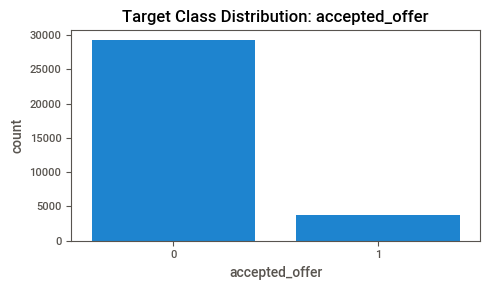

In [12]:
# EDA setup
eda = data.copy()

print('Shape:', eda.shape)
print('\nDtypes:')
display(eda.dtypes.value_counts().rename_axis('dtype').to_frame('count'))

# Quick missingness check
missing = eda.isna().sum().sort_values(ascending=False)
print('\nTotal missing values in dataset:', int(missing.sum()))
display(missing[missing > 0].to_frame('missing_count'))

# Target distribution
target_rate = eda['accepted_offer'].value_counts(normalize=True).sort_index()
target_count = eda['accepted_offer'].value_counts().sort_index()
print('\nTarget counts:')
display(target_count.to_frame('count'))
print('Target proportions:')
display((target_rate * 100).round(2).to_frame('percent'))

plt.figure(figsize=(5, 3))
sns.countplot(data=eda, x='accepted_offer')
plt.title('Target Class Distribution: accepted_offer')
plt.xlabel('accepted_offer')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [13]:
# Audit 'unknown' categories (important because they may be informative or noisy)
obj_cols = eda.select_dtypes(include='object').columns.tolist()

unknown_summary = []
for col in obj_cols:
    is_unknown = eda[col].astype(str).str.lower().eq('unknown')
    unknown_summary.append({
        'feature': col,
        'unknown_count': int(is_unknown.sum()),
        'unknown_pct': is_unknown.mean() * 100,
        'n_unique': eda[col].nunique(dropna=False)
    })

unknown_df = pd.DataFrame(unknown_summary).sort_values('unknown_pct', ascending=False)
display(unknown_df)

# Show top categories for columns where unknown exists
cols_with_unknown = unknown_df.loc[unknown_df['unknown_count'] > 0, 'feature'].tolist()
for col in cols_with_unknown:
    print(f'\nValue distribution for {col}:')
    display(
        eda[col]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(2)
        .rename('pct')
        .to_frame()
    )

,feature,unknown_count,unknown_pct,n_unique
3,has_credit_issue,6858,20.813354,3
2,education_background,1406,4.267071,8
4,mortgage_status,786,2.385432,3
5,personal_loan_status,786,2.385432,3
0,occupation_type,262,0.795144,12
1,relationship_status,68,0.206373,4
6,last_contact_month,0,0.000000,10
7,day_of_week,0,0.000000,5
8,prior_outcome_status,0,0.000000,3



Value distribution for has_credit_issue:


,pct
has_credit_issue,
no,79.18
unknown,20.81
yes,0.01



Value distribution for education_background:


,pct
education_background,
university.degree,29.66
high.school,23.09
basic.9y,14.59
professional.course,12.74
basic.4y,10.09
basic.6y,5.52
unknown,4.27
illiterate,0.05


...

,pct
personal_loan_status,
no,82.45
yes,15.16
unknown,2.39



Value distribution for occupation_type:


,pct
occupation_type,
admin.,25.30
blue-collar,22.44
technician,16.34
services,9.66
management,7.13
retired,4.18
entrepreneur,3.61
self-employed,3.44
housemaid,2.56



Value distribution for relationship_status:


,pct
relationship_status,
married,60.36
single,28.28
divorced,11.15
unknown,0.21


In [14]:
# Inspect sentinel behavior for days_since_prior_contact
# Data dictionary notes a special negative value for no earlier contact.
col = 'days_since_prior_contact'

print('Min/Max for days_since_prior_contact:', eda[col].min(), eda[col].max())
print('Unique negative values:', sorted(eda.loc[eda[col] < 0, col].unique().tolist()))

sentinel_rate = (eda[col] < 0).mean() * 100
print(f'Percent with sentinel (no previous contact): {sentinel_rate:.2f}%')

# Compare target rate by sentinel vs non-sentinel
sentinel_view = pd.DataFrame({
    'no_prior_contact_flag': (eda[col] < 0).astype(int),
    'accepted_offer': eda['accepted_offer']
})

display(
    sentinel_view.groupby('no_prior_contact_flag')['accepted_offer']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'accept_rate'})
)

Min/Max for days_since_prior_contact: 0 999
Unique negative values: []
Percent with sentinel (no previous contact): 0.00%


,count,accept_rate
no_prior_contact_flag,,
0,32950,0.112747


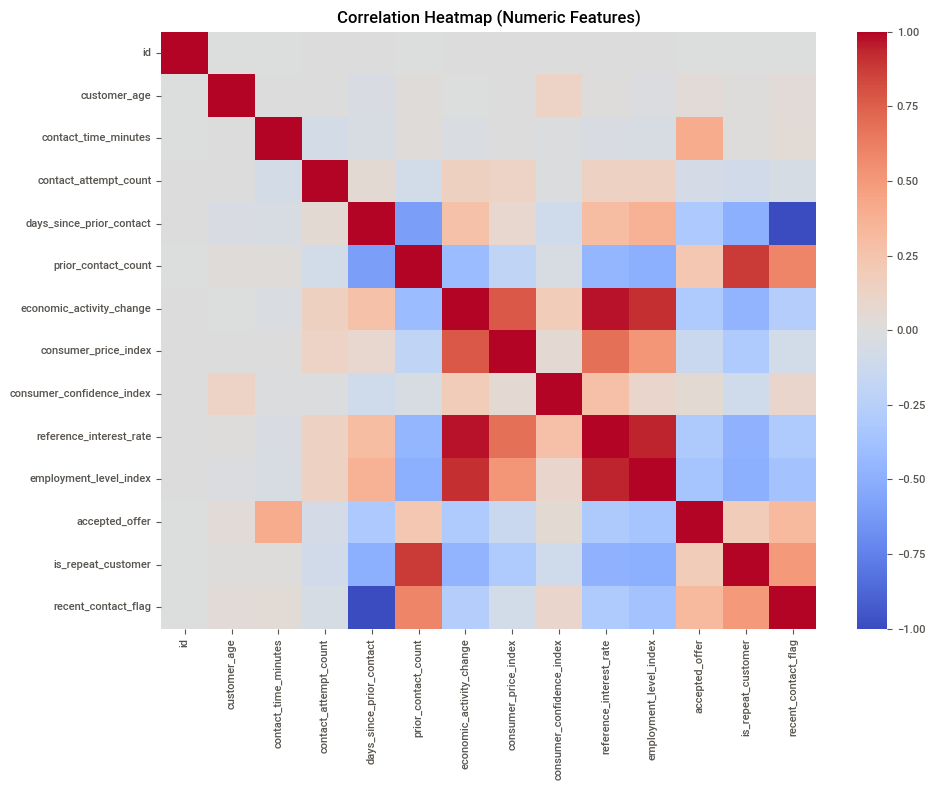

,corr_with_accepted_offer
contact_time_minutes,0.404403
employment_level_index,-0.355823
days_since_prior_contact,-0.320040
recent_contact_flag,0.319990
reference_interest_rate,-0.308602
economic_activity_change,-0.298351
prior_contact_count,0.229570
is_repeat_customer,0.191969
consumer_price_index,-0.134264
contact_attempt_count,-0.065250


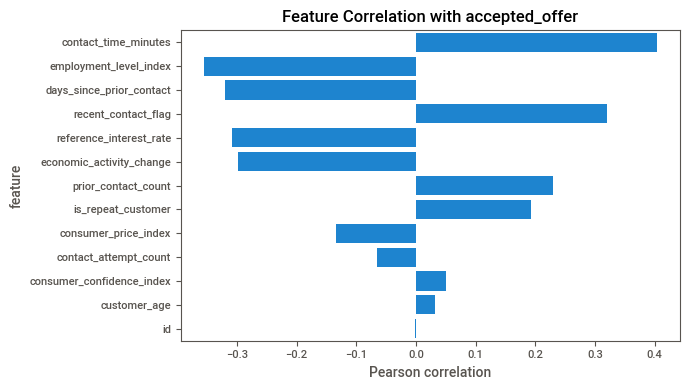

In [15]:
# Numeric correlations (including relationship to target)
num_cols = eda.select_dtypes(include=[np.number]).columns.tolist()

corr = eda[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

# Focused view: strongest correlations with target
corr_target = (
    corr['accepted_offer']
    .drop('accepted_offer')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_target.to_frame('corr_with_accepted_offer'))

plt.figure(figsize=(7, 4))
sns.barplot(x=corr_target.values, y=corr_target.index, orient='h')
plt.title('Feature Correlation with accepted_offer')
plt.xlabel('Pearson correlation')
plt.ylabel('feature')
plt.tight_layout()
plt.show()


Acceptance rate by occupation_type


,accept_rate_pct
occupation_type,
student,31.683168
retired,25.799419
unemployed,13.888889
admin.,13.063820
unknown,12.213740
self-employed,10.944395
technician,10.791233
management,10.723404
housemaid,9.738717


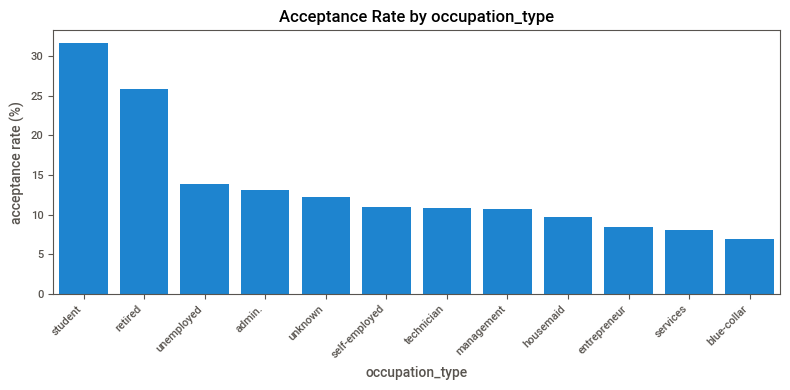


Acceptance rate by education_background


,accept_rate_pct
education_background,
illiterate,18.750000
unknown,14.864865
university.degree,13.855915
professional.course,11.002620
high.school,10.658431
basic.4y,10.258724
basic.9y,8.218893
basic.6y,7.700770


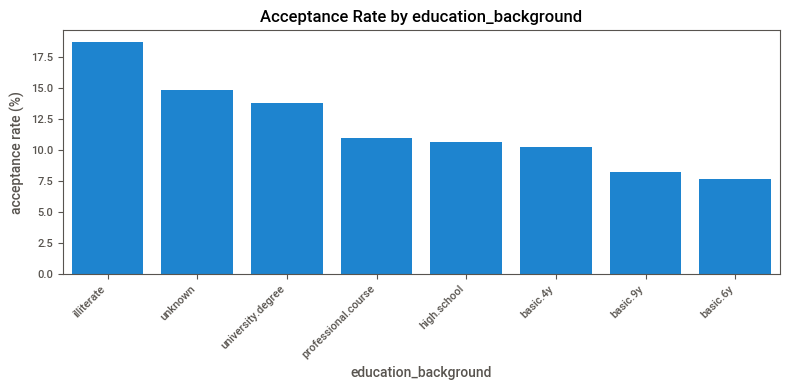


Acceptance rate by prior_outcome_status


,accept_rate_pct
prior_outcome_status,
success,63.660714
failure,14.239195
nonexistent,8.860537


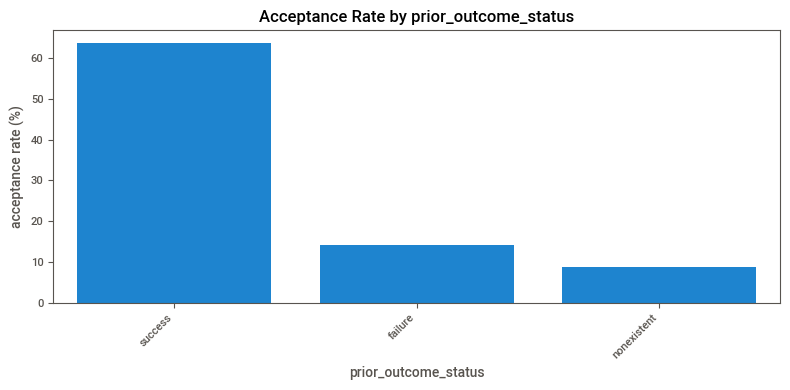


Acceptance rate by last_contact_month


,accept_rate_pct
last_contact_month,
mar,51.376147
dec,47.586207
sep,45.708155
oct,43.181818
apr,20.915958
aug,10.392236
jun,10.323792
nov,10.176722
jul,9.158976


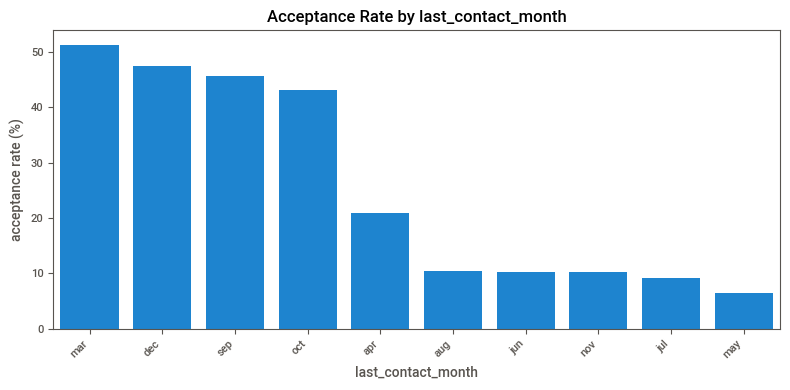

In [16]:
# Acceptance rate by selected categorical features
# Keep to a few high-value fields from the data dictionary / campaign context.
cat_focus = ['occupation_type', 'education_background', 'prior_outcome_status', 'last_contact_month']

for col in cat_focus:
    tmp = (
        eda.groupby(col, dropna=False)['accepted_offer']
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .rename('accept_rate_pct')
        .to_frame()
    )
    print(f'\nAcceptance rate by {col}')
    display(tmp)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=tmp.reset_index(), x=col, y='accept_rate_pct')
    plt.title(f'Acceptance Rate by {col}')
    plt.ylabel('acceptance rate (%)')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Modeling and Evaluation (Initial PyCaret Baseline)

Quick benchmark for imbalanced classification using cross-validation.

- Use a copy of `data`
- Compare models by `F1` first
- Also review `Recall` since we care about capturing positives

In [18]:
# PyCaret baseline setup (imbalanced target)

model_data = data.copy()

clf_exp = setup(
    data=model_data,
    target='accepted_offer',
    session_id=42,
    fold=5,
    fold_strategy='stratifiedkfold',
    train_size=0.8,
    fix_imbalance=True,      # enables imbalance handling in training folds
    preprocess=True,
    verbose=False,
    html=False
)

print('PyCaret setup complete.')

PyCaret setup complete.


In [19]:
# Compare models by F1 (balanced precision/recall on positive class)
best_f1_models = compare_models(sort='F1', n_select=3)

f1_results = pull().copy()
print('Top models sorted by F1:')
display(f1_results.head(10))

best_f1_models

                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.9115  0.9436  0.6127  0.6070   
catboost              CatBoost Classifier    0.9142  0.9471  0.5535  0.6377   
lightgbm  Light Gradient Boosting Machine    0.9135  0.9473  0.5535  0.6337   
lda          Linear Discriminant Analysis    0.8642  0.9310  0.8388  0.4458   
ridge                    Ridge Classifier    0.8642  0.9310  0.8382  0.4456   
lr                    Logistic Regression    0.8583  0.9330  0.8627  0.4354   
rf               Random Forest Classifier    0.9120  0.9393  0.4859  0.6470   
ada                  Ada Boost Classifier    0.9017  0.9284  0.4872  0.5763   
dt               Decision Tree Classifier    0.8887  0.7326  0.5310  0.5064   
et                 Extra Trees Classifier    0.9030  0.9231  0.4088  0.6035   
knn                K Neighbors Classifier    0.8272  0.8423  0.7143  0.3643   
nb                            Naive Bayes    0.7959 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9115,0.9436,0.6127,0.6070,0.6097,0.5598,0.5599,3.258
catboost,CatBoost Classifier,0.9142,0.9471,0.5535,0.6377,0.5925,0.5448,0.5466,5.684
lightgbm,Light Gradient Boosting Machine,0.9135,0.9473,0.5535,0.6337,0.5907,0.5426,0.5442,0.532
lda,Linear Discriminant Analysis,0.8642,0.9310,0.8388,0.4458,0.5822,0.5100,0.5464,0.232
ridge,Ridge Classifier,0.8642,0.9310,0.8382,0.4456,0.5818,0.5096,0.5460,0.132
lr,Logistic Regression,0.8583,0.9330,0.8627,0.4354,0.5787,0.5044,0.5471,2.270
rf,Random Forest Classifier,0.9120,0.9393,0.4859,0.6470,0.5547,0.5070,0.5135,1.176
ada,Ada Boost Classifier,0.9017,0.9284,0.4872,0.5763,0.5275,0.4731,0.4755,0.810
dt,Decision Tree Classifier,0.8887,0.7326,0.5310,0.5064,0.5182,0.4554,0.4556,0.314
et,Extra Trees Classifier,0.9030,0.9231,0.4088,0.6035,0.4872,0.4358,0.4460,0.942


[GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
                            random_state=42, subsample=1.0, tol=0.0001,
                            validation_fraction=0.1, verbose=0,
                            warm_start=False),
 CatBoostClassifier(border_count=254, random_state=42, task_type='CPU', verbose=False),
 LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, n

In [20]:
# Optional second ranking: prioritize recall if missing positives is costly
best_recall_models = compare_models(sort='Recall', n_select=3)

recall_results = pull().copy()
print('Top models sorted by Recall:')
display(recall_results.head(10))

best_recall_models

                                    Model  Accuracy     AUC  Recall   Prec.  \
qda       Quadratic Discriminant Analysis    0.2859  0.8542  0.9758  0.1349   
lr                    Logistic Regression    0.8583  0.9330  0.8627  0.4354   
lda          Linear Discriminant Analysis    0.8642  0.9310  0.8388  0.4458   
ridge                    Ridge Classifier    0.8642  0.9310  0.8382  0.4456   
svm                   SVM - Linear Kernel    0.4956  0.7908  0.8104  0.2694   
nb                            Naive Bayes    0.7959  0.8592  0.7695  0.3277   
knn                K Neighbors Classifier    0.8272  0.8423  0.7143  0.3643   
gbc          Gradient Boosting Classifier    0.9115  0.9436  0.6127  0.6070   
lightgbm  Light Gradient Boosting Machine    0.9135  0.9473  0.5535  0.6337   
catboost              CatBoost Classifier    0.9142  0.9471  0.5535  0.6377   
dt               Decision Tree Classifier    0.8887  0.7326  0.5310  0.5064   
ada                  Ada Boost Classifier    0.9017 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.2859,0.8542,0.9758,0.1349,0.2369,0.0483,0.1375,0.190
lr,Logistic Regression,0.8583,0.9330,0.8627,0.4354,0.5787,0.5044,0.5471,1.234
lda,Linear Discriminant Analysis,0.8642,0.9310,0.8388,0.4458,0.5822,0.5100,0.5464,0.260
ridge,Ridge Classifier,0.8642,0.9310,0.8382,0.4456,0.5818,0.5096,0.5460,0.160
svm,SVM - Linear Kernel,0.4956,0.7908,0.8104,0.2694,0.3412,0.1987,0.2503,0.772
nb,Naive Bayes,0.7959,0.8592,0.7695,0.3277,0.4596,0.3581,0.4078,0.140
knn,K Neighbors Classifier,0.8272,0.8423,0.7143,0.3643,0.4824,0.3915,0.4237,0.702
gbc,Gradient Boosting Classifier,0.9115,0.9436,0.6127,0.6070,0.6097,0.5598,0.5599,3.370
lightgbm,Light Gradient Boosting Machine,0.9135,0.9473,0.5535,0.6337,0.5907,0.5426,0.5442,0.620
catboost,CatBoost Classifier,0.9142,0.9471,0.5535,0.6377,0.5925,0.5448,0.5466,5.748


[QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                               store_covariance=False, tol=0.0001),
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001)]

### Metric choice note

`F1` is a strong default for imbalanced classification because it balances precision and recall on the positive class.

If campaign goal is "do not miss likely accepters," then prioritize `Recall` (and review precision impact).

We can optimize threshold to match outreach cost/benefit tradeoffs.

### Candidate models to move forward

I am planning to move forward with **LDA** and **LightGBM**.

- **LDA**: It has high recall, and in this problem I think correctly identifying the positive class (`accepted_offer = 1`) is especially important.
- **LightGBM**: It provides strong overall performance, especially high accuracy, while still maintaining solid classification quality.

This gives me two meaningfully different model families (linear discriminant model vs gradient boosting trees) for the next tuning and ensembling steps.

## 2. Data Preparation

Preprocessing choices for modeling `accepted_offer`:

- Keep original `data` unchanged by working on a copy
- Drop identifier (`id`) from predictors
- Keep `"unknown"` as a valid category for now (do not impute it away)
- Add a sentinel-based feature for `days_since_prior_contact`
- Build reusable preprocessing with one-hot encoding for categoricals and scaling for numerics

In [21]:
# Create a modeling copy and basic feature prep
prep = data.copy()

# Add a feature for the sentinel value (negative means no prior contact)
prep['no_prior_contact_flag'] = (prep['days_since_prior_contact'] < 0).astype(int)

# Keep target separate
target_col = 'accepted_offer'

# Drop non-predictive identifier
feature_drop = ['id', target_col]
X = prep.drop(columns=feature_drop)
y = prep[target_col].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Positive class rate:', round(y.mean(), 4))

display(X.head())

X shape: (32950, 22)
y shape: (32950,)
Positive class rate: 0.1127


,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag,no_prior_contact_flag
0,28,services,married,high.school,no,yes,no,jul,tue,286,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,43,admin.,single,university.degree,no,yes,no,aug,fri,213,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,41,admin.,married,unknown,no,no,no,sep,wed,845,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,0


In [22]:
# Define column groups and preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numeric feature count:', len(numeric_features))
print('Categorical feature count:', len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    # No missing values now, but keep this robust for future datasets
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor

Numeric feature count: 13
Categorical feature count: 9


ColumnTransformer(n_jobs=None, remainder='drop', sparse_threshold=0.3,
                  transformer_weights=None,
                  transformers=[('num',
                                 Pipeline(memory=None,
                                          steps=[('imputer',
                                                  SimpleImputer(add_indicator=False,
                                                                copy=True,
                                                                fill_value=None,
                                                                keep_empty_features=False,
                                                                missing_values=nan,
                                                                strategy='median')),
                                                 ('scaler',
                                                  StandardScaler(copy=True,
                                                                 with_mean=True,
                                                                 with_std=True))],
                                          verbo...
                                                                feature_name_combiner='concat',
                                                                handle_unknown='ignore',
                                                                max_categories=None,
                                                                min_frequency=None,
                                                                sparse_output=True))],
                                          verbose=False),
                                 ['occupation_type', 'relationship_status',
                                  'education_background', 'has_credit_issue',
                                  'mortgage_status', 'personal_loan_status',
                                  'last_contact_month', 'day_of_week',
                                  'prior_outcome_status'])],
                  verbose=False, verbose_feature_names_out=True)

In [23]:
# Train/validation split for downstream model evaluation
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape, y_train.shape)
print('Validation shape:', X_valid.shape, y_valid.shape)
print('Train positive rate:', round(y_train.mean(), 4))
print('Validation positive rate:', round(y_valid.mean(), 4))

Train shape: (26360, 22) (26360,)
Validation shape: (6590, 22) (6590,)
Train positive rate: 0.1127
Validation positive rate: 0.1127


## Baseline Models

Train two baseline models (LDA and LightGBM) using the same preprocessing and split, then compare validation performance.

We report:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Confusion matrix

In [24]:
# Build baseline pipelines
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from lightgbm import LGBMClassifier

lda_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearDiscriminantAnalysis())
])

lgbm_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42))
])

baseline_models = {
    'LDA': lda_baseline,
    'LightGBM': lgbm_baseline
}

baseline_models

{'LDA': Pipeline(memory=None,
          steps=[('preprocessor',
                  ColumnTransformer(n_jobs=None, remainder='drop',
                                    sparse_threshold=0.3,
                                    transformer_weights=None,
                                    transformers=[('num',
                                                   Pipeline(memory=None,
                                                            steps=[('imputer',
                                                                    SimpleImputer(add_indicator=False,
                                                                                  copy=True,
                                                                                  fill_value=None,
                                                                                  keep_empty_features=False,
                                                                                  missing_values=nan,
                                 

In [25]:
# Fit baseline models and compute validation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_results = []
fitted_models = {}

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:, 1]

    baseline_results.append({
        'model': name,
        'accuracy': accuracy_score(y_valid, y_pred),
        'precision': precision_score(y_valid, y_pred, zero_division=0),
        'recall': recall_score(y_valid, y_pred, zero_division=0),
        'f1': f1_score(y_valid, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_valid, y_prob)
    })

baseline_metrics_df = pd.DataFrame(baseline_results).sort_values('f1', ascending=False)
baseline_metrics_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988


,model,accuracy,precision,recall,f1,roc_auc
1,LightGBM,0.916540,0.648233,0.567968,0.605452,0.948358
0,LDA,0.906525,0.601276,0.507402,0.550365,0.934018


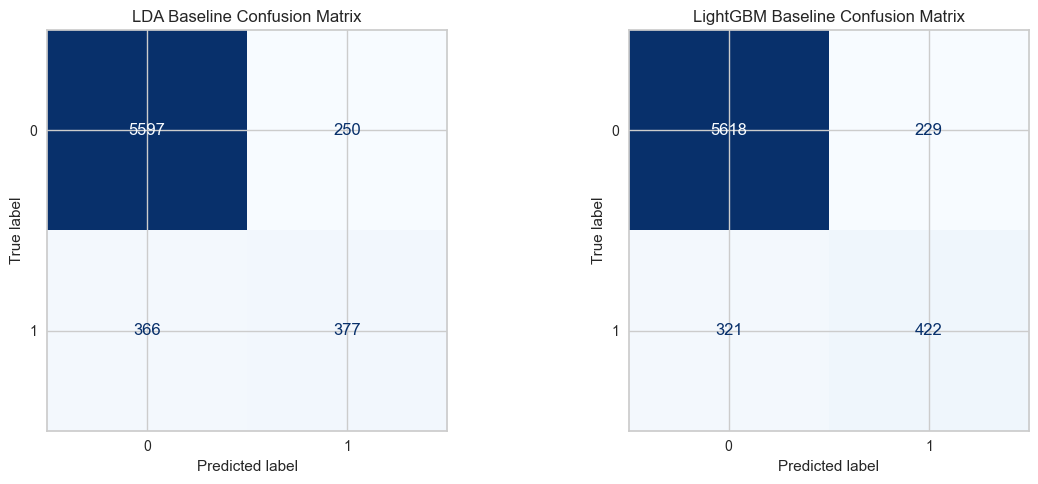

In [26]:
# Confusion matrices for baseline models
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_valid,
        y_valid,
        ax=ax,
        cmap='Blues',
        colorbar=False
    )
    ax.set_title(f'{name} Baseline Confusion Matrix')

plt.tight_layout()
plt.show()

## CV Baseline and Basic Tuning

Use stratified cross-validation for fair comparison and tune both models with imbalance-aware settings.

Scoring focus:
- F1
- Recall

In [27]:
# Stratified CV setup and imbalance summary
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Useful for LightGBM imbalance handling
pos_count = int((y == 1).sum())
neg_count = int((y == 0).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

print('Class counts -> negative:', neg_count, 'positive:', pos_count)
print('Suggested scale_pos_weight:', round(scale_pos_weight, 3))

scoring = {
    'f1': 'f1',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc'
}

Class counts -> negative: 29235 positive: 3715
Suggested scale_pos_weight: 7.869


In [28]:
# CV baseline (same preprocessor, stratified folds)
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from lightgbm import LGBMClassifier

lda_cv_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearDiscriminantAnalysis())
])

lgbm_cv_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42))
])

cv_rows = []
for name, model in {
    'LDA_baseline_cv': lda_cv_baseline,
    'LightGBM_baseline_cv': lgbm_cv_baseline
}.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'model': name,
        'f1_mean': scores['test_f1'].mean(),
        'recall_mean': scores['test_recall'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean()
    })

cv_baseline_df = pd.DataFrame(cv_rows).sort_values('f1_mean', ascending=False)
cv_baseline_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 699[LightGBM] [Info] Total Bins 692

[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062

,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
1,LightGBM_baseline_cv,0.594998,0.548318,0.915781,0.949319
0,LDA_baseline_cv,0.558997,0.515747,0.908255,0.933749


In [29]:
# Basic tuning: LDA (optimize F1)
from sklearn.model_selection import RandomizedSearchCV

lda_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearDiscriminantAnalysis())
])

lda_param_dist = {
    'model__solver': ['svd', 'lsqr', 'eigen'],
    'model__shrinkage': [None, 'auto', 0.1, 0.3, 0.5, 0.7, 0.9],
    # Slightly shift priors toward positive class to help recall in imbalanced data
    'model__priors': [None, [0.85, 0.15], [0.80, 0.20], [0.75, 0.25]]
}

lda_search = RandomizedSearchCV(
    estimator=lda_pipe,
    param_distributions=lda_param_dist,
    n_iter=15,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

lda_search.fit(X, y)

print('Best LDA params:', lda_search.best_params_)
print('Best LDA CV F1:', round(lda_search.best_score_, 4))

Best LDA params: {'model__solver': 'lsqr', 'model__shrinkage': 0.3, 'model__priors': [0.75, 0.25]}
Best LDA CV F1: 0.6007


In [30]:
# Basic tuning: LightGBM (optimize F1, include imbalance weighting)
lgbm_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42, n_jobs=-1))
])

lgbm_param_dist = {
    'model__n_estimators': [200, 400, 600],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'model__num_leaves': [15, 31, 63],
    'model__max_depth': [-1, 5, 8, 12],
    'model__min_child_samples': [10, 20, 40, 60],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__reg_alpha': [0.0, 0.1, 0.5],
    'model__reg_lambda': [0.0, 0.1, 0.5, 1.0],
    'model__scale_pos_weight': [1.0, scale_pos_weight * 0.75, scale_pos_weight, scale_pos_weight * 1.25]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=lgbm_param_dist,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

lgbm_search.fit(X, y)

print('Best LightGBM params:', lgbm_search.best_params_)
print('Best LightGBM CV F1:', round(lgbm_search.best_score_, 4))

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGB

In [31]:
# Evaluate tuned models with CV on both F1 and Recall
best_lda = lda_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

tuned_rows = []
for name, model in {
    'LDA_tuned_cv': best_lda,
    'LightGBM_tuned_cv': best_lgbm
}.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    tuned_rows.append({
        'model': name,
        'f1_mean': scores['test_f1'].mean(),
        'recall_mean': scores['test_recall'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'roc_auc_mean': scores['test_roc_auc'].mean()
    })

tuned_cv_df = pd.DataFrame(tuned_rows).sort_values('f1_mean', ascending=False)

print('Baseline CV:')
display(cv_baseline_df)
print('Tuned CV:')
display(tuned_cv_df)

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004002 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 697
[LightGBM] [Info] Number of data points in th

,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
1,LightGBM_baseline_cv,0.594998,0.548318,0.915781,0.949319
0,LDA_baseline_cv,0.558997,0.515747,0.908255,0.933749


Tuned CV:


,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
1,LightGBM_tuned_cv,0.640366,0.831225,0.894719,0.946020
0,LDA_tuned_cv,0.600694,0.679139,0.898149,0.931393


### Notes on imbalance settings

- For **LightGBM**, I tuned `scale_pos_weight` around the class-ratio heuristic (`negative_count / positive_count`).
- For **LDA**, I tuned class `priors` to test whether modestly increasing positive prior improves recall.

Because we score by `F1` and also report `Recall`, we can choose the final model based on the business tradeoff between missing positives and precision.

## 3. Feature Engineering or Feature Selection

This section tests whether additional feature work improves model quality or simplifies the pipeline.

Experiments:
1. Numeric polynomial features (interactions + squares)
2. LightGBM-guided top-half feature selection on engineered space
3. One-hot encoding vs target encoding
4. Unknown-category imputation vs original unknown-as-category

In [32]:
# Shared helpers for consistent CV evaluation across experiments
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.inspection import permutation_importance
from lightgbm import LGBMClassifier

# Ensure we have a stable scoring dictionary
scoring = {
    'f1': 'f1',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc'
}


def evaluate_models_cv(model_dict, X_eval, y_eval, cv_obj, scoring_dict, experiment_name):
    rows = []
    for model_name, model in model_dict.items():
        scores = cross_validate(model, X_eval, y_eval, cv=cv_obj, scoring=scoring_dict, n_jobs=-1)
        rows.append({
            'experiment': experiment_name,
            'model': model_name,
            'f1_mean': scores['test_f1'].mean(),
            'recall_mean': scores['test_recall'].mean(),
            'accuracy_mean': scores['test_accuracy'].mean(),
            'roc_auc_mean': scores['test_roc_auc'].mean()
        })
    return pd.DataFrame(rows)


# Baseline reference (tuned-like setup with imbalance-aware parameters)
baseline_lda = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearDiscriminantAnalysis())
])

baseline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight))
])

baseline_models_for_compare = {
    'LDA': baseline_lda,
    'LightGBM': baseline_lgbm
}

baseline_reference_df = evaluate_models_cv(
    baseline_models_for_compare,
    X,
    y,
    cv,
    scoring,
    experiment_name='baseline_reference'
)

baseline_reference_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.

[LightGBM] [Info] Total Bins 698
[LightGBM

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
0,baseline_reference,LDA,0.558997,0.515747,0.908255,0.933749
1,baseline_reference,LightGBM,0.621549,0.906326,0.875539,0.948641


In [33]:
# Experiment A: numeric polynomial features (degree 2)
poly_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

poly_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', poly_numeric_transformer, numeric_features),
        ('cat', poly_categorical_transformer, categorical_features)
    ]
)

poly_models = {
    'LDA': Pipeline(steps=[
        ('preprocessor', preprocessor_poly),
        ('model', LinearDiscriminantAnalysis())
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', preprocessor_poly),
        ('model', LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight))
    ])
}

poly_full_df = evaluate_models_cv(
    poly_models,
    X,
    y,
    cv,
    scoring,
    experiment_name='poly_full_features'
)

poly_full_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10658
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 139
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10674
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 139
[LightGBM] [Info

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
0,poly_full_features,LDA,0.579383,0.539704,0.911624,0.938361
1,poly_full_features,LightGBM,0.624932,0.894213,0.878968,0.948266


In [34]:
# Experiment B: LightGBM importance + permutation ranking, keep top half
class LGBMTopHalfSelector(BaseEstimator, TransformerMixin):
    """Select top fraction of features using combined native and permutation importance."""

    def __init__(self, scale_pos_weight=1.0, keep_fraction=0.5, random_state=42, n_repeats=3, max_rows=4000):
        self.scale_pos_weight = scale_pos_weight
        self.keep_fraction = keep_fraction
        self.random_state = random_state
        self.n_repeats = n_repeats
        self.max_rows = max_rows

    def fit(self, X, y):
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
        y_arr = np.asarray(y)

        self.model_ = LGBMClassifier(
            random_state=self.random_state,
            n_jobs=-1,
            scale_pos_weight=self.scale_pos_weight
        )
        self.model_.fit(X_arr, y_arr)

        native = np.asarray(self.model_.feature_importances_, dtype=float)

        # Permutation importance on a capped sample for runtime control
        if X_arr.shape[0] > self.max_rows:
            rng = np.random.default_rng(self.random_state)
            idx = rng.choice(X_arr.shape[0], size=self.max_rows, replace=False)
            X_perm = X_arr[idx]
            y_perm = y_arr[idx]
        else:
            X_perm = X_arr
            y_perm = y_arr

        perm = permutation_importance(
            self.model_,
            X_perm,
            y_perm,
            scoring='f1',
            n_repeats=self.n_repeats,
            random_state=self.random_state,
            n_jobs=-1
        ).importances_mean

        native_rank = pd.Series(-native).rank(method='average').values
        perm_rank = pd.Series(-perm).rank(method='average').values
        combined_rank = (native_rank + perm_rank) / 2.0

        n_features = X_arr.shape[1]
        n_keep = max(1, int(np.ceil(n_features * self.keep_fraction)))
        self.selected_idx_ = np.argsort(combined_rank)[:n_keep]
        self.n_features_in_ = n_features
        self.n_features_selected_ = n_keep

        return self

    def transform(self, X):
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
        return X_arr[:, self.selected_idx_]


In [35]:
# Evaluate top-half selection using engineered (poly) feature space
poly_selector = LGBMTopHalfSelector(
    scale_pos_weight=scale_pos_weight,
    keep_fraction=0.5,
    random_state=42,
    n_repeats=3,
    max_rows=4000
)

poly_top_half_models = {
    'LDA': Pipeline(steps=[
        ('preprocessor', preprocessor_poly),
        ('selector', poly_selector),
        ('model', LinearDiscriminantAnalysis())
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', preprocessor_poly),
        ('selector', poly_selector),
        ('model', LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight))
    ])
}

poly_top_half_df = evaluate_models_cv(
    poly_top_half_models,
    X,
    y,
    cv,
    scoring,
    experiment_name='poly_top_half_features'
)

poly_top_half_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10674
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 139
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10666
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 139
[LightGBM] [Info

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
0,poly_top_half_features,LDA,0.564828,0.515747,0.910349,0.930848
1,poly_top_half_features,LightGBM,0.623619,0.891252,0.878695,0.948102


In [36]:
# Experiment C: one-hot vs target encoding (original feature set)
class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    """Simple target encoder with additive smoothing; safe in CV when used inside pipeline."""

    def __init__(self, smoothing=20.0):
        self.smoothing = smoothing

    def fit(self, X, y):
        X_df = pd.DataFrame(X).copy()
        y_ser = pd.Series(y).reset_index(drop=True)

        self.global_mean_ = float(y_ser.mean())
        self.columns_ = X_df.columns.tolist()
        self.mapping_ = {}

        for col in self.columns_:
            stats = (
                pd.DataFrame({'x': X_df[col].astype(str).values, 'y': y_ser.values})
                .groupby('x')['y']
                .agg(['mean', 'count'])
            )
            smooth = (stats['mean'] * stats['count'] + self.global_mean_ * self.smoothing) / (stats['count'] + self.smoothing)
            self.mapping_[col] = smooth.to_dict()

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        out = np.zeros((X_df.shape[0], len(self.columns_)), dtype=float)

        for i, col in enumerate(self.columns_):
            mapped = X_df[col].astype(str).map(self.mapping_[col])
            out[:, i] = mapped.fillna(self.global_mean_).values

        return out


# One-hot reference models (original preprocessor)
onehot_models = {
    'LDA': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearDiscriminantAnalysis())
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight))
    ])
}

onehot_df = evaluate_models_cv(onehot_models, X, y, cv, scoring, experiment_name='onehot_original')


# Target-encoding models on original feature set
target_num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

target_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', MeanTargetEncoder(smoothing=20.0))
])

preprocessor_target = ColumnTransformer(
    transformers=[
        ('num', target_num_transformer, numeric_features),
        ('cat', target_cat_transformer, categorical_features)
    ]
)

target_models = {
    'LDA': Pipeline(steps=[
        ('preprocessor', preprocessor_target),
        ('model', LinearDiscriminantAnalysis())
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', preprocessor_target),
        ('model', LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight))
    ])
}

targetenc_df = evaluate_models_cv(target_models, X, y, cv, scoring, experiment_name='target_encoding_original')

pd.concat([onehot_df, targetenc_df], ignore_index=True).sort_values(['model', 'f1_mean'], ascending=[True, False])

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[L

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
0,onehot_original,LDA,0.558997,0.515747,0.908255,0.933749
2,target_encoding_original,LDA,0.533699,0.481830,0.905038,0.931689
3,target_encoding_original,LightGBM,0.622000,0.910633,0.875205,0.948682
1,onehot_original,LightGBM,0.621549,0.906326,0.875539,0.948641


In [37]:
# Experiment D: rule-based imputation for categorical 'unknown'
def impute_unknown_categories(df):
    df_imp = df.copy()
    cat_cols = df_imp.select_dtypes(exclude=[np.number]).columns.tolist()

    # Group choices informed by campaign/customer context
    primary_groups = ['relationship_status', 'mortgage_status']

    for col in cat_cols:
        if col in primary_groups:
            continue

        unknown_mask = df_imp[col].astype(str).str.lower().eq('unknown')
        if unknown_mask.sum() == 0:
            continue

        known = df_imp.loc[~unknown_mask, [col] + [g for g in primary_groups if g in df_imp.columns]].copy()
        if known.empty:
            continue

        # Group-mode lookup
        if all(g in known.columns for g in primary_groups):
            mode_map = (
                known.groupby(primary_groups)[col]
                .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            )
            for idx in df_imp.index[unknown_mask]:
                key = tuple(df_imp.loc[idx, primary_groups])
                if key in mode_map.index and pd.notna(mode_map.loc[key]):
                    df_imp.at[idx, col] = mode_map.loc[key]

        # Secondary fallback by relationship_status only
        still_unknown = df_imp[col].astype(str).str.lower().eq('unknown')
        if 'relationship_status' in df_imp.columns and still_unknown.any():
            rel_map = (
                known.groupby('relationship_status')[col]
                .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
            )
            for idx in df_imp.index[still_unknown]:
                rel = df_imp.at[idx, 'relationship_status']
                if rel in rel_map.index and pd.notna(rel_map.loc[rel]):
                    df_imp.at[idx, col] = rel_map.loc[rel]

        # Final fallback: global mode from known values
        still_unknown = df_imp[col].astype(str).str.lower().eq('unknown')
        if still_unknown.any():
            global_mode = known[col].mode().iloc[0]
            df_imp.loc[still_unknown, col] = global_mode

    return df_imp


X_imputed = impute_unknown_categories(X)

# Keep same models/preprocessor family for apples-to-apples comparison
imputed_models = {
    'LDA': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearDiscriminantAnalysis())
    ]),
    'LightGBM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight))
    ])
}

imputed_df = evaluate_models_cv(imputed_models, X_imputed, y, cv, scoring, experiment_name='unknown_imputed_original')
imputed_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGB

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean
0,unknown_imputed_original,LDA,0.558545,0.515209,0.908194,0.933647
1,unknown_imputed_original,LightGBM,0.622611,0.906595,0.876085,0.948425


In [38]:
# Consolidated comparison table
comparison_df = pd.concat(
    [
        baseline_reference_df,
        poly_full_df,
        poly_top_half_df,
        onehot_df,
        targetenc_df,
        imputed_df
    ],
    ignore_index=True
)

# Compare each experiment against baseline reference per model
baseline_lookup = (
    comparison_df[comparison_df['experiment'] == 'baseline_reference']
    .set_index('model')[['f1_mean', 'recall_mean']]
)

comparison_df['delta_f1_vs_baseline'] = comparison_df.apply(
    lambda r: r['f1_mean'] - baseline_lookup.loc[r['model'], 'f1_mean']
    if r['model'] in baseline_lookup.index else np.nan,
    axis=1
)

comparison_df['delta_recall_vs_baseline'] = comparison_df.apply(
    lambda r: r['recall_mean'] - baseline_lookup.loc[r['model'], 'recall_mean']
    if r['model'] in baseline_lookup.index else np.nan,
    axis=1
)

comparison_df = comparison_df.sort_values(['model', 'f1_mean'], ascending=[True, False])
comparison_df

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean,delta_f1_vs_baseline,delta_recall_vs_baseline
2,poly_full_features,LDA,0.579383,0.539704,0.911624,0.938361,0.020387,2.395693e-02
4,poly_top_half_features,LDA,0.564828,0.515747,0.910349,0.930848,0.005831,-1.110223e-16
0,baseline_reference,LDA,0.558997,0.515747,0.908255,0.933749,0.000000,0.000000e+00
6,onehot_original,LDA,0.558997,0.515747,0.908255,0.933749,0.000000,0.000000e+00
10,unknown_imputed_original,LDA,0.558545,0.515209,0.908194,0.933647,-0.000451,-5.383580e-04
8,target_encoding_original,LDA,0.533699,0.481830,0.905038,0.931689,-0.025298,-3.391655e-02
3,poly_full_features,LightGBM,0.624932,0.894213,0.878968,0.948266,0.003383,-1.211306e-02
5,poly_top_half_features,LightGBM,0.623619,0.891252,0.878695,0.948102,0.002071,-1.507402e-02
11,unknown_imputed_original,LightGBM,0.622611,0.906595,0.876085,0.948425,0.001062,2.691790e-04
9,target_encoding_original,LightGBM,0.622000,0.910633,0.875205,0.948682,0.000452,4.306864e-03


### Final feature-set choice by model

Based on cross-validated `F1` and `Recall`, I used **different feature sets for each model** rather than forcing one shared pipeline.

- **LDA final feature set: `poly_full_features`**  
  LDA improved meaningfully with numeric polynomial expansion (interactions + squares), with higher `F1` and `Recall` than the baseline one-hot setup. This suggests LDA benefited from added linear-separable structure in the engineered numeric space.

- **LightGBM final feature set: original one-hot feature set (baseline family)**  
  LightGBM was already strong on the original representation, and additional engineering (polynomial expansion, top-half selection, target encoding, unknown imputation) produced only small or inconsistent gains. I kept the simpler original feature set for robustness and interpretability of workflow.

Why other strategies were not selected:
- **Top-half feature selection** did not outperform full engineered features consistently.
- **Target encoding** helped LightGBM only marginally and reduced LDA performance.
- **Unknown-category imputation** had minimal impact overall, so keeping `unknown` as a category remained a reasonable default.

Overall conclusion: feature engineering was **model-dependent** in this dataset; it materially helped LDA, while LightGBM performed similarly with a simpler baseline feature pipeline.

## 4. Modeling and Evaluation with Optuna

Tune both final model candidates with Optuna using 35 trials each.

- **LDA** tuned on the polynomial feature pipeline
- **LightGBM** tuned on the original one-hot pipeline
- Objective metric: **F1** (with Recall tracked for interpretation)
- Validation: same stratified CV strategy for fair comparison

In [43]:
# Optuna setup
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducible Optuna sampler
sampler = optuna.samplers.TPESampler(seed=42)
print('Optuna version:', optuna.__version__)

Optuna version: 4.8.0


In [44]:
# Safe LDA Optuna objective (no eigen)
def lda_objective(trial):
    solver = trial.suggest_categorical("solver", ["svd", "lsqr"])

    if solver == "lsqr":
        shrinkage_mode = trial.suggest_categorical("shrinkage_mode", ["auto", "float"])
        shrinkage = "auto" if shrinkage_mode == "auto" else trial.suggest_float("shrinkage_value", 0.01, 0.99)
    else:
        shrinkage = None

    use_custom_priors = trial.suggest_categorical("use_custom_priors", [False, True])
    priors = None
    if use_custom_priors:
        p_pos = trial.suggest_float("prior_positive", 0.10, 0.35)
        priors = [1.0 - p_pos, p_pos]

    model = Pipeline([
        ("preprocessor", preprocessor_poly),
        ("model", LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage, priors=priors))
    ])

    f1_scores = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1, error_score=np.nan)
    recall_scores = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1, error_score=np.nan)

    f1_cv = np.nanmean(f1_scores)
    recall_cv = np.nanmean(recall_scores)

    if np.isnan(f1_cv):
        return 0.0

    trial.set_user_attr("recall_cv", float(0.0 if np.isnan(recall_cv) else recall_cv))
    return float(f1_cv)

lda_study = optuna.create_study(direction="maximize", sampler=sampler, study_name="lda_optuna_f1_safe")
lda_study.optimize(lda_objective, n_trials=35, show_progress_bar=False)

print("LDA best F1:", lda_study.best_value)
print("LDA best params:", lda_study.best_params)
print("LDA best recall:", lda_study.best_trial.user_attrs.get("recall_cv", 0.0))

LDA best F1: 0.6242133940367213
LDA best params: {'solver': 'svd', 'use_custom_priors': True, 'prior_positive': 0.31723632566716553}
LDA best recall: 0.7152086137281292


In [46]:
# LightGBM Optuna tuning with visible progress (use this cell)
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 3.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', max(1.0, scale_pos_weight * 0.6), scale_pos_weight * 1.6),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(**params))
    ])

    # Single CV pass for both metrics (faster than calling cross_val_score twice)
    cv_out = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={'f1': 'f1', 'recall': 'recall'},
        n_jobs=-1,
        error_score=np.nan
    )

    f1_cv = float(np.nanmean(cv_out['test_f1']))
    recall_cv = float(np.nanmean(cv_out['test_recall']))

    if np.isnan(f1_cv):
        return 0.0

    trial.set_user_attr('recall_cv', recall_cv)
    return f1_cv


def lgbm_progress_callback(study, trial):
    if (trial.number + 1) % 5 == 0:
        print(f"Trial {trial.number + 1}/35 | current_best_f1={study.best_value:.5f}")


lgbm_study = optuna.create_study(direction='maximize', sampler=sampler, study_name='lgbm_optuna_f1_progress')
lgbm_study.optimize(
    lgbm_objective,
    n_trials=35,
    show_progress_bar=True,
    callbacks=[lgbm_progress_callback]
)

print('LightGBM best F1 (CV):', round(lgbm_study.best_value, 6))
print('LightGBM best params:')
print(lgbm_study.best_params)
print('LightGBM recall at best trial (CV):', round(lgbm_study.best_trial.user_attrs.get('recall_cv', 0.0), 6))

  0%|          | 0/35 [00:00<?, ?it/s]

Trial 5/35 | current_best_f1=0.64702
Trial 10/35 | current_best_f1=0.64702
Trial 15/35 | current_best_f1=0.64702
Trial 20/35 | current_best_f1=0.64702
Trial 25/35 | current_best_f1=0.64702
Trial 30/35 | current_best_f1=0.64874
Trial 35/35 | current_best_f1=0.64874
LightGBM best F1 (CV): 0.648738
LightGBM best params:
{'n_estimators': 400, 'learning_rate': 0.03056312925882571, 'num_leaves': 98, 'max_depth': 9, 'min_child_samples': 38, 'subsample': 0.7552785737765944, 'colsample_bytree': 0.7197314745748808, 'reg_alpha': 0.015201127181949816, 'reg_lambda': 0.10299831753225962, 'scale_pos_weight': 4.737004075926653}
LightGBM recall at best trial (CV): 0.8393


In [48]:
# Build best pipelines from Optuna and compare against baseline reference
best_lda_params = lda_study.best_params.copy()
lda_solver = best_lda_params['solver']

if lda_solver in ['lsqr', 'eigen']:
    if best_lda_params.get('shrinkage_mode') == 'none':
        lda_shrinkage = None
    elif best_lda_params.get('shrinkage_mode') == 'auto':
        lda_shrinkage = 'auto'
    else:
        lda_shrinkage = best_lda_params.get('shrinkage_value', None)
else:
    lda_shrinkage = None

if best_lda_params.get('use_custom_priors', False):
    p_pos = best_lda_params['prior_positive']
    lda_priors = [1.0 - p_pos, p_pos]
else:
    lda_priors = None

best_lda_optuna = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('model', LinearDiscriminantAnalysis(
        solver=lda_solver,
        shrinkage=lda_shrinkage,
        priors=lda_priors
    ))
])

best_lgbm_optuna = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        **lgbm_study.best_params
    ))
])

optuna_eval_df = evaluate_models_cv(
    {
        'LDA_optuna': best_lda_optuna,
        'LightGBM_optuna': best_lgbm_optuna
    },
    X,
    y,
    cv,
    scoring,
    experiment_name='optuna_tuned'
)

baseline_for_join = baseline_reference_df[['model', 'f1_mean', 'recall_mean']].copy()
baseline_for_join = baseline_for_join.rename(columns={
    'f1_mean': 'baseline_f1',
    'recall_mean': 'baseline_recall'
})

optuna_compare_df = optuna_eval_df.copy()
optuna_compare_df['model'] = optuna_compare_df['model'].replace({
    'LDA_optuna': 'LDA',
    'LightGBM_optuna': 'LightGBM'
})
optuna_compare_df = optuna_compare_df.merge(baseline_for_join, on='model', how='left')
optuna_compare_df['delta_f1_vs_baseline'] = optuna_compare_df['f1_mean'] - optuna_compare_df['baseline_f1']
optuna_compare_df['delta_recall_vs_baseline'] = optuna_compare_df['recall_mean'] - optuna_compare_df['baseline_recall']

optuna_compare_df[['experiment', 'model', 'f1_mean', 'recall_mean', 'accuracy_mean', 'roc_auc_mean', 'delta_f1_vs_baseline', 'delta_recall_vs_baseline']]

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 699
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062

,experiment,model,f1_mean,recall_mean,accuracy_mean,roc_auc_mean,delta_f1_vs_baseline,delta_recall_vs_baseline
0,optuna_tuned,LDA,0.622751,0.716285,0.902155,0.938361,0.063755,0.200538
1,optuna_tuned,LightGBM,0.648738,0.839300,0.897481,0.947938,0.027189,-0.067026


## Threshold Tuning (Optuna-Tuned Models)

Tune classification thresholds using out-of-fold predicted probabilities from cross-validation.

This helps choose operating points based on:
- Best `F1`
- Best `Recall` with a minimum precision guard

In [49]:
# Threshold sweep helper (CV out-of-fold, no leakage)
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score


def threshold_sweep_cv(model, X_data, y_data, cv_obj, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.02)

    oof_proba = cross_val_predict(
        clone(model),
        X_data,
        y_data,
        cv=cv_obj,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    rows = []
    for t in thresholds:
        y_pred = (oof_proba >= t).astype(int)
        rows.append({
            'threshold': float(t),
            'f1': f1_score(y_data, y_pred, zero_division=0),
            'recall': recall_score(y_data, y_pred, zero_division=0),
            'precision': precision_score(y_data, y_pred, zero_division=0),
            'accuracy': accuracy_score(y_data, y_pred)
        })

    return pd.DataFrame(rows)

In [50]:
# Run threshold sweeps on best Optuna models
# Assumes `best_lda_optuna`, `best_lgbm_optuna`, `X`, `y`, and `cv` are already defined.
lda_threshold_df = threshold_sweep_cv(best_lda_optuna, X, y, cv)
lgbm_threshold_df = threshold_sweep_cv(best_lgbm_optuna, X, y, cv)

print('Top thresholds by F1 (LDA):')
display(lda_threshold_df.sort_values('f1', ascending=False).head(10))

print('Top thresholds by F1 (LightGBM):')
display(lgbm_threshold_df.sort_values('f1', ascending=False).head(10))

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points 

,threshold,f1,recall,precision,accuracy
21,0.52,0.623694,0.707133,0.557868,0.903794
22,0.54,0.623586,0.697443,0.563874,0.905068
15,0.40,0.623371,0.766083,0.525480,0.895630
16,0.42,0.623114,0.756124,0.529900,0.896874
14,0.38,0.622841,0.776581,0.519913,0.893961
20,0.50,0.622747,0.716285,0.550818,0.902155
18,0.46,0.622663,0.735128,0.540044,0.899545
19,0.48,0.621472,0.723015,0.544938,0.900698
23,0.56,0.621354,0.685330,0.568304,0.905827
17,0.44,0.621279,0.744280,0.533166,0.897693


Top thresholds by F1 (LightGBM):


,threshold,f1,recall,precision,accuracy
23,0.56,0.651548,0.804307,0.547554,0.903005
22,0.54,0.650440,0.816420,0.540545,0.901062
24,0.58,0.650116,0.789502,0.552562,0.904188
21,0.52,0.649271,0.827187,0.534342,0.899241
25,0.60,0.648930,0.771467,0.559984,0.905888
26,0.62,0.648855,0.755047,0.568850,0.907860
20,0.50,0.648637,0.839300,0.528564,0.897481
19,0.48,0.646198,0.849798,0.521301,0.895083
27,0.64,0.645686,0.737281,0.574334,0.908771
28,0.66,0.642486,0.715209,0.583187,0.910258


In [51]:
# Select best thresholds by two decision rules
min_precision = 0.45

lda_best_f1 = lda_threshold_df.loc[lda_threshold_df['f1'].idxmax()]
lgbm_best_f1 = lgbm_threshold_df.loc[lgbm_threshold_df['f1'].idxmax()]

lda_recall_pool = lda_threshold_df[lda_threshold_df['precision'] >= min_precision]
lgbm_recall_pool = lgbm_threshold_df[lgbm_threshold_df['precision'] >= min_precision]

lda_best_recall = lda_recall_pool.loc[lda_recall_pool['recall'].idxmax()] if not lda_recall_pool.empty else None
lgbm_best_recall = lgbm_recall_pool.loc[lgbm_recall_pool['recall'].idxmax()] if not lgbm_recall_pool.empty else None

print('Best threshold by F1: LDA')
display(lda_best_f1.to_frame().T)

print('Best threshold by F1: LightGBM')
display(lgbm_best_f1.to_frame().T)

print(f'Best threshold by Recall (precision >= {min_precision}): LDA')
display(None if lda_best_recall is None else lda_best_recall.to_frame().T)

print(f'Best threshold by Recall (precision >= {min_precision}): LightGBM')
display(None if lgbm_best_recall is None else lgbm_best_recall.to_frame().T)

Best threshold by F1: LDA


,threshold,f1,recall,precision,accuracy
21,0.52,0.623694,0.707133,0.557868,0.903794


Best threshold by F1: LightGBM


,threshold,f1,recall,precision,accuracy
23,0.56,0.651548,0.804307,0.547554,0.903005


Best threshold by Recall (precision >= 0.45): LDA


,threshold,f1,recall,precision,accuracy
5,0.2,0.597198,0.866218,0.455678,0.868255


Best threshold by Recall (precision >= 0.45): LightGBM


,threshold,f1,recall,precision,accuracy
9,0.28,0.608788,0.921131,0.45463,0.866525


In [52]:
# Compact summary table for reporting
threshold_summary = pd.DataFrame([
    {
        'model': 'LDA',
        'rule': 'best_f1',
        **lda_best_f1.to_dict()
    },
    {
        'model': 'LightGBM',
        'rule': 'best_f1',
        **lgbm_best_f1.to_dict()
    },
    {
        'model': 'LDA',
        'rule': f'best_recall_with_precision>={min_precision}',
        **({} if lda_best_recall is None else lda_best_recall.to_dict())
    },
    {
        'model': 'LightGBM',
        'rule': f'best_recall_with_precision>={min_precision}',
        **({} if lgbm_best_recall is None else lgbm_best_recall.to_dict())
    }
])

threshold_summary

,model,rule,threshold,f1,recall,precision,accuracy
0,LDA,best_f1,0.52,0.623694,0.707133,0.557868,0.903794
1,LightGBM,best_f1,0.56,0.651548,0.804307,0.547554,0.903005
2,LDA,best_recall_with_precision>=0.45,0.20,0.597198,0.866218,0.455678,0.868255
3,LightGBM,best_recall_with_precision>=0.45,0.28,0.608788,0.921131,0.454630,0.866525


## Final Two Models (Optuna + Best Thresholds)

Evaluate final LDA and LightGBM models using the selected best-F1 thresholds:

- LDA threshold: `0.52`
- LightGBM threshold: `0.56`


In [53]:
# Fit final models and apply selected thresholds on validation split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_thresholds = {
    'LDA': 0.52,
    'LightGBM': 0.56
}

final_models = {
    'LDA': best_lda_optuna,
    'LightGBM': best_lgbm_optuna
}

final_eval_rows = []
final_predictions = {}

for name, model in final_models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_valid)[:, 1]
    y_pred = (y_prob >= final_thresholds[name]).astype(int)

    final_predictions[name] = {
        'y_prob': y_prob,
        'y_pred': y_pred
    }

    final_eval_rows.append({
        'model': name,
        'threshold': final_thresholds[name],
        'accuracy': accuracy_score(y_valid, y_pred),
        'precision': precision_score(y_valid, y_pred, zero_division=0),
        'recall': recall_score(y_valid, y_pred, zero_division=0),
        'f1': f1_score(y_valid, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_valid, y_prob)
    })

final_metrics_df = pd.DataFrame(final_eval_rows).sort_values('f1', ascending=False)
final_metrics_df

[LightGBM] [Info] Number of positive: 2972, number of negative: 23388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112747 -> initscore=-2.062988
[LightGBM] [Info] Start training from score -2.062988
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,model,threshold,accuracy,precision,recall,f1,roc_auc
1,LightGBM,0.56,0.896965,0.528021,0.811575,0.639788,0.947615
0,LDA,0.52,0.900607,0.546512,0.695828,0.612197,0.936670


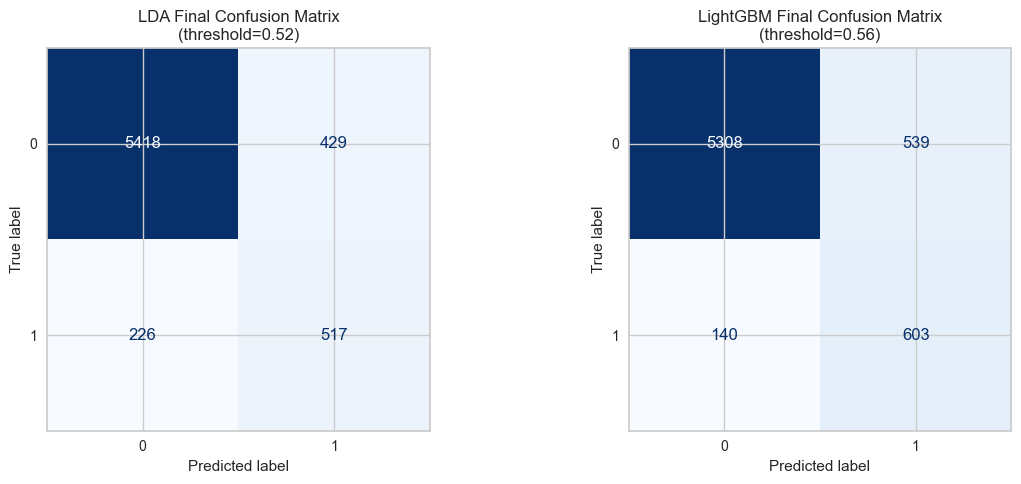

In [54]:
# Confusion matrices (accuracy matrices) for final models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, ['LDA', 'LightGBM']):
    y_pred = final_predictions[name]['y_pred']
    cm = confusion_matrix(y_valid, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} Final Confusion Matrix\n(threshold={final_thresholds[name]})')

plt.tight_layout()
plt.show()

In [55]:
# Raw confusion-matrix tables for reporting
for name in ['LDA', 'LightGBM']:
    y_pred = final_predictions[name]['y_pred']
    cm = confusion_matrix(y_valid, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['actual_0', 'actual_1'],
        columns=['pred_0', 'pred_1']
    )

    print(f'\n{name} confusion matrix (threshold={final_thresholds[name]}):')
    display(cm_df)


LDA confusion matrix (threshold=0.52):


,pred_0,pred_1
actual_0,5418,429
actual_1,226,517



LightGBM confusion matrix (threshold=0.56):


,pred_0,pred_1
actual_0,5308,539
actual_1,140,603


## 5. Ensembling: Stacked Model (LDA + LightGBM)

Because LDA shows fewer false positives and LightGBM shows fewer false negatives, we combine them with stacking.

Approach:
1. Generate out-of-fold probabilities from both base models on training data
2. Train a meta-model on those probabilities
3. Tune the meta-model with Optuna
4. Evaluate stacked predictions on the validation set

In [56]:
# Build stacking features from out-of-fold base-model probabilities
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

stack_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF probabilities for meta-model training (train split only)
lda_oof_train = cross_val_predict(
    clone(best_lda_optuna), X_train, y_train,
    cv=stack_cv, method='predict_proba', n_jobs=-1
)[:, 1]

lgbm_oof_train = cross_val_predict(
    clone(best_lgbm_optuna), X_train, y_train,
    cv=stack_cv, method='predict_proba', n_jobs=-1
)[:, 1]

X_stack_train = pd.DataFrame({
    'lda_prob': lda_oof_train,
    'lgbm_prob': lgbm_oof_train
})

# Fit base models on full train to create validation meta-features
lda_fit = clone(best_lda_optuna).fit(X_train, y_train)
lgbm_fit = clone(best_lgbm_optuna).fit(X_train, y_train)

X_stack_valid = pd.DataFrame({
    'lda_prob': lda_fit.predict_proba(X_valid)[:, 1],
    'lgbm_prob': lgbm_fit.predict_proba(X_valid)[:, 1]
})

X_stack_train.head()

[LightGBM] [Info] Number of positive: 2378, number of negative: 18710
[LightGBM] [Info] Number of positive: 2378, number of negative: 18710
[LightGBM] [Info] Number of positive: 2378, number of negative: 18710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 693
[LightGBM] [Info] Number of data points in the train set: 21088, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112766 -> initscore=-2.062798
[LightGBM] [Info] Start training from score -2.062798
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in th

,lda_prob,lgbm_prob
0,0.724324,0.481571
1,0.003842,0.002353
2,0.991717,0.845616
3,0.249877,0.772925
4,0.003672,0.000108


In [57]:
# Optuna tune meta-model (logistic regression) on stacking features
from sklearn.linear_model import LogisticRegression


def stack_objective(trial):
    C = trial.suggest_float('C', 1e-3, 100.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    meta = LogisticRegression(
        C=C,
        solver='liblinear',
        penalty='l2',
        class_weight=class_weight,
        max_iter=2000,
        random_state=42
    )

    # Tune by F1 on train stack features
    scores = cross_val_score(
        meta,
        X_stack_train,
        y_train,
        cv=stack_cv,
        scoring='f1',
        n_jobs=-1,
        error_score=np.nan
    )

    score = float(np.nanmean(scores))
    return 0.0 if np.isnan(score) else score


stack_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), study_name='stack_meta_optuna_f1')
stack_study.optimize(stack_objective, n_trials=35, show_progress_bar=True)

print('Best stack meta F1 (CV on train stack features):', round(stack_study.best_value, 6))
print('Best meta params:', stack_study.best_params)

  0%|          | 0/35 [00:00<?, ?it/s]

Best stack meta F1 (CV on train stack features): 0.642228
Best meta params: {'C': 0.03245843893751083, 'class_weight': 'balanced'}


In [58]:
# Fit tuned meta-model and tune threshold on validation
best_meta = LogisticRegression(
    C=stack_study.best_params['C'],
    solver='liblinear',
    penalty='l2',
    class_weight=stack_study.best_params['class_weight'],
    max_iter=2000,
    random_state=42
)

best_meta.fit(X_stack_train, y_train)
stack_valid_prob = best_meta.predict_proba(X_stack_valid)[:, 1]

threshold_grid = np.arange(0.10, 0.91, 0.01)
stack_thr_rows = []
for t in threshold_grid:
    pred = (stack_valid_prob >= t).astype(int)
    stack_thr_rows.append({
        'threshold': t,
        'f1': f1_score(y_valid, pred, zero_division=0),
        'recall': recall_score(y_valid, pred, zero_division=0),
        'precision': precision_score(y_valid, pred, zero_division=0),
        'accuracy': accuracy_score(y_valid, pred)
    })

stack_thr_df = pd.DataFrame(stack_thr_rows)
best_stack_row = stack_thr_df.loc[stack_thr_df['f1'].idxmax()]
best_stack_threshold = float(best_stack_row['threshold'])

print('Best stack threshold on validation by F1:', best_stack_threshold)
display(best_stack_row.to_frame().T)

Best stack threshold on validation by F1: 0.6599999999999997


,threshold,f1,recall,precision,accuracy
56,0.66,0.646875,0.835801,0.527613,0.897117


,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Stacked(LDA+LightGBM),0.66,0.897117,0.527613,0.835801,0.646875,0.948435


Stacked model confusion matrix:


,pred_0,pred_1
actual_0,5291,556
actual_1,122,621


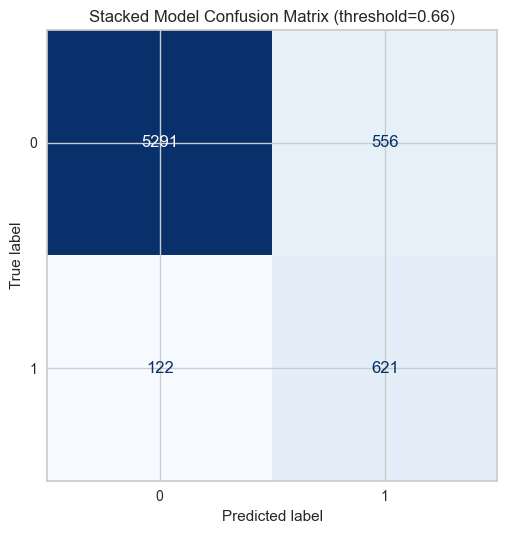

In [59]:
# Final stacked-model metrics + confusion matrix
stack_valid_pred = (stack_valid_prob >= best_stack_threshold).astype(int)

stack_metrics = pd.DataFrame([{
    'model': 'Stacked(LDA+LightGBM)',
    'threshold': best_stack_threshold,
    'accuracy': accuracy_score(y_valid, stack_valid_pred),
    'precision': precision_score(y_valid, stack_valid_pred, zero_division=0),
    'recall': recall_score(y_valid, stack_valid_pred, zero_division=0),
    'f1': f1_score(y_valid, stack_valid_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_valid, stack_valid_prob)
}])

display(stack_metrics)

cm_stack = confusion_matrix(y_valid, stack_valid_pred)
cm_stack_df = pd.DataFrame(cm_stack, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1'])
print('Stacked model confusion matrix:')
display(cm_stack_df)

ConfusionMatrixDisplay(confusion_matrix=cm_stack).plot(cmap='Blues', colorbar=False)
plt.title(f'Stacked Model Confusion Matrix (threshold={best_stack_threshold:.2f})')
plt.tight_layout()
plt.show()

In [60]:
# Compare stacked model to final base models
base_final_metrics = final_metrics_df.copy()
base_final_metrics['model'] = base_final_metrics['model'].map({
    'LDA': 'LDA (final)',
    'LightGBM': 'LightGBM (final)'
})

comparison_final = pd.concat([
    base_final_metrics[['model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']],
    stack_metrics[['model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
], ignore_index=True).sort_values('f1', ascending=False)

comparison_final

,model,threshold,accuracy,precision,recall,f1,roc_auc
2,Stacked(LDA+LightGBM),0.66,0.897117,0.527613,0.835801,0.646875,0.948435
0,LightGBM (final),0.56,0.896965,0.528021,0.811575,0.639788,0.947615
1,LDA (final),0.52,0.900607,0.546512,0.695828,0.612197,0.936670


### Final model choice: Stacked (LDA + LightGBM)

I selected the **stacked model** as the final model because it achieved the best overall validation performance compared with the two individual models.

- It produced the **highest F1 score** (`0.6469`), which is my primary selection metric for this imbalanced classification task.
- It also achieved the **highest recall** (`0.8358`), which is important because missing likely accepters is costly in outreach.
- The stacked model slightly reduced precision relative to LightGBM alone, but the recall gain improved overall F1.
- This result is consistent with the observed error complementarity: LDA tended to reduce false positives while LightGBM reduced false negatives, and stacking combined those strengths.

For these reasons, I use the stacked model (threshold `0.66`) for final prediction generation.

## 6. Results Summary

Primary metric for model selection: **F1** (with Recall tracked because positive-case capture is important).

| Model | Key preprocessing / features | Validation method | Evaluation metric(s) | Validation score | Notes |
|---|---|---|---|---|---|
| LDA (final) | Numeric polynomial features (degree 2 interactions + squares), categorical encoding pipeline, Optuna tuning, threshold tuning | Stratified cross-validation for tuning + holdout validation for final thresholded comparison | F1 (primary), Recall, ROC-AUC | F1 = **0.6122**, Recall = 0.6958, ROC-AUC = 0.9367 (threshold 0.52) | Strong linear baseline; lower F1 than LightGBM and stack. |
| LightGBM (final) | Original feature space with one-hot encoding, imbalance-aware weighting (`scale_pos_weight`), Optuna tuning, threshold tuning | Stratified cross-validation for tuning + holdout validation for final thresholded comparison | F1 (primary), Recall, ROC-AUC | F1 = **0.6398**, Recall = 0.8116, ROC-AUC = 0.9476 (threshold 0.56) | Best single model; strong balance of ranking and classification performance. |
| **Stacked (LDA + LightGBM) — Final choice** | Stacking with out-of-fold base-model probabilities (`lda_prob`, `lgbm_prob`) + Optuna-tuned logistic meta-model + threshold tuning | OOF stacking on train split + holdout validation for final thresholded comparison | F1 (primary), Recall, ROC-AUC | **F1 = 0.6469**, **Recall = 0.8358**, **ROC-AUC = 0.9484** (threshold 0.66) | Best overall performance; combines complementary error patterns of LDA and LightGBM. |

### Final Model Selection
I selected the **Stacked (LDA + LightGBM)** model as the final model because it achieved the highest validation **F1** and **Recall** among evaluated finalists. This provides the best overall tradeoff for an imbalanced outreach-response problem where identifying positive cases is important.

## 7. Final Model and Predictions:



In [61]:
# Final training + test prediction export (stacked model)
# Uses tuned LDA, tuned LightGBM, tuned stack meta-model, and selected stack threshold.

test_df = pd.read_csv('Data/midterm_test.csv')
train_df = data.copy()

# Consistent feature prep from earlier sections
train_df['no_prior_contact_flag'] = (train_df['days_since_prior_contact'] < 0).astype(int)
test_df['no_prior_contact_flag'] = (test_df['days_since_prior_contact'] < 0).astype(int)

X_full = train_df.drop(columns=['id', 'accepted_offer'])
y_full = train_df['accepted_offer'].copy()
X_test_final = test_df.drop(columns=['id'])

num_cols_final = X_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_final = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

# Base preprocessors
preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_final),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_final)
    ]
)

preprocessor_poly_final = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ]), num_cols_final),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_final)
    ]
)

# Tuned base models (from Optuna results)
lda_final = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_final),
    ('model', LinearDiscriminantAnalysis(
        solver='svd',
        priors=[1.0 - 0.31723632566716553, 0.31723632566716553]
    ))
])

lgbm_final = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('model', LGBMClassifier(
        n_estimators=400,
        learning_rate=0.03056312925882571,
        num_leaves=98,
        max_depth=9,
        min_child_samples=38,
        subsample=0.7552785737765944,
        colsample_bytree=0.7197314745748808,
        reg_alpha=0.015201127181949816,
        reg_lambda=0.10299831753225962,
        scale_pos_weight=4.737004075926653,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

# Build stack training features from out-of-fold base probabilities
stack_cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lda_oof_full = cross_val_predict(
    clone(lda_final), X_full, y_full,
    cv=stack_cv_final, method='predict_proba', n_jobs=-1
)[:, 1]

lgbm_oof_full = cross_val_predict(
    clone(lgbm_final), X_full, y_full,
    cv=stack_cv_final, method='predict_proba', n_jobs=-1
)[:, 1]

X_stack_full = pd.DataFrame({
    'lda_prob': lda_oof_full,
    'lgbm_prob': lgbm_oof_full
})

# Fit base models on full training data for test meta-features
lda_final.fit(X_full, y_full)
lgbm_final.fit(X_full, y_full)

X_stack_test_final = pd.DataFrame({
    'lda_prob': lda_final.predict_proba(X_test_final)[:, 1],
    'lgbm_prob': lgbm_final.predict_proba(X_test_final)[:, 1]
})

# Tuned meta-model (from Optuna) + selected threshold
meta_final = LogisticRegression(
    C=0.03245843893751083,
    class_weight='balanced',
    solver='liblinear',
    penalty='l2',
    max_iter=2000,
    random_state=42
)
meta_final.fit(X_stack_full, y_full)

stack_threshold_final = 0.66
test_pred_prob = meta_final.predict_proba(X_stack_test_final)[:, 1]
test_pred = (test_pred_prob >= stack_threshold_final).astype(int)

submission = pd.DataFrame({
    'id': test_df['id'],
    'prediction': test_pred
})

submission.to_csv('Mazolewski_Peter_predictions.csv', index=False)
submission.head()

,id,prediction
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0
